# Dados e Educação: Priorização de Intervenções Educacionais no Brasil

#### Análise socioeducacional baseada em indicadores públicos e priorização orientada por dados

---

# 1. Introdução

A educação pública brasileira apresenta desafios significativos, especialmente em contextos de maior vulnerabilidade socioeconômica. Diferenças regionais, desigualdade de renda e acesso desigual a recursos impactam diretamente o desempenho educacional dos estudantes.

Diante desse cenário, o uso de dados pode apoiar decisões mais eficientes sobre onde e como priorizar intervenções educacionais.

Com base em dados oficiais, este projeto realiza uma análise do desempenho educacional no Brasil, combinando indicadores socioeconômicos e educacionais para identificar contextos prioritários para intervenção, com foco especial em desigualdades relacionadas à educação pública.


A partir dessa análise, o projeto também simula a implementação e o acompanhamento de um piloto educacional orientado por dados, considerando definição de indicadores, priorização e monitoramento de resultados.


# 2. Problema de negócio

Diante de recursos limitados, como identificar as regiões onde intervenções educacionais podem gerar maior impacto?

Além disso:

- Quais fatores socioeconômicos estão mais associados ao desempenho educacional?
- Como priorizar contextos educacionais com maior vulnerabilidade e necessidade de intervenção?
- Quais indicadores devem ser acompanhados durante a implementação do piloto educacional?
- Como avaliar se uma intervenção está funcionando ao longo do tempo?

Este projeto busca responder a essas questões com base em dados reais e simulações aplicadas ao contexto da educação pública.

A análise possui foco aplicado e utiliza indicadores educacionais e socioeconômicos em nível estadual para apoiar processos de priorização, monitoramento e avaliação de projetos educacionais.

# 3. Escopo do projeto

Este projeto foca em:

- análise de indicadores educacionais e socioeconômicos em nível estadual
- análise de diferenças entre contextos educacionais públicos e privados
- identificação de contextos de maior vulnerabilidade
- priorização de regiões para intervenção educacional
- simulação de acompanhamento de um piloto educacional

O foco está na aplicação prática de dados para apoio à tomada de decisão no contexto da educação pública.

# 4. Dados utilizados e preparação dos dados

Os dados utilizados neste projeto foram obtidos a partir de bases públicas oficiais brasileiras, com foco em indicadores educacionais e socioeconômicos.

As principais fontes utilizadas foram:

- SAEB (INEP)
- IBGE / SIDRA
- PNAD Contínua
- Censo Demográfico

Como referência principal para o desempenho educacional, foram utilizados os dados do **SAEB 2023**, ano mais recente disponível. Para manter comparabilidade temporal entre os indicadores, foram priorizadas informações socioeconômicas referentes ao mesmo período. Para a taxa de urbanização, foram utilizados dados do Censo Demográfico 2022.

Os dados passaram por etapas de tratamento e padronização para garantir consistência, comparabilidade e integração entre as diferentes bases utilizadas na análise. Foram exibidas pequenas amostras dos dados de cada base para verificação.

Após o tratamento, as bases foram consolidadas em um único dataset por meio da variável `estado`, utilizada como chave comum entre os indicadores educacionais e socioeconômicos.

Inicialmente, os dados foram importados para o ambiente de análise:

In [1]:
!pip uninstall -y kaleido
!pip install kaleido==0.2.1

Found existing installation: kaleido 0.2.1
Uninstalling kaleido-0.2.1:
  Successfully uninstalled kaleido-0.2.1
  Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl (79.9 MB)


In [2]:
import pandas as pd; from google.colab import drive; drive.mount('/content/drive', force_remount=True)
df_saeb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/11.Desempenho_Educacional/data/saeb3_pop.xlsx")
df_renda = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/11.Desempenho_Educacional/data/renda_estados.xlsx", skiprows=3)
df_gini = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/11.Desempenho_Educacional/data/gini_estados.xlsx", skiprows=3)
df_pobreza = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/11.Desempenho_Educacional/data/estados_pobreza.xlsx", skiprows=3)
df_urb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/11.Desempenho_Educacional/data/taxa_urbanizacao.xlsx", skiprows=4)
df_esc = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/11.Desempenho_Educacional/data/escolaridade2.xlsx", skiprows=3)

Mounted at /content/drive


## 4.1 Desempenho educacional (SAEB)

Os dados de desempenho educacional foram obtidos a partir do SAEB (Sistema de Avaliação da Educação Básica), utilizando médias de desempenho dos **estudantes do 9º ano** por estado em **Língua Portuguesa** e **Matemática**.

A análise priorizou o desempenho da rede pública, considerando o foco do projeto em educação pública e intervenções educacionais. Também foram utilizadas informações complementares sobre desempenho total e desempenho da rede privada.

- Variável `desempenho`: média de desempenho da rede pública
- Variável `desempenho_privado`: média de desempenho da rede privada
- Variável `populacao`: população estimada dos estados brasileiros, utilizada apenas para fins ilustrativos nas visualizações
- Unidade: escala contínua de proficiência educacional

De forma geral:

- valores próximos de **230** indicam menores níveis de desempenho observados
- valores próximos de **250** representam níveis intermediários
- valores acima de **260** indicam os maiores desempenhos observados

A média de desempenho das escolas públicas brasileiras na análise foi de aproximadamente **248 pontos**.

In [3]:
df_saeb = df_saeb.rename(columns={"NO_UF": "estado","Pub_Med9_M_P": "desempenho","Priv_Med9_M_P": "desempenho_privado","Pop_2024": "populacao"})
df_saeb["estado"] = df_saeb["estado"].str.upper().str.strip()
df_saeb = df_saeb[["estado", "desempenho", "desempenho_privado", "populacao"]]
df_saeb.sample(5, random_state=40)

,estado,desempenho,desempenho_privado,populacao
2,AMAPÁ,236.555,284.220,806517
16,PERNAMBUCO,249.115,288.430,9562007
19,RIO GRANDE DO NORTE,236.420,299.065,3455236
14,PARAÍBA,241.125,285.445,4164468
15,PARANÁ,264.525,275.835,11890517


## 4.2 Indicadores socioeconômicos (IBGE - SIDRA)

Os indicadores socioeconômicos foram obtidos a partir do **IBGE**, por meio do sistema **SIDRA**, com base principalmente na PNAD Contínua e no Censo Demográfico.

As variáveis selecionadas buscam representar diferentes dimensões socioeconômicas relacionadas ao desempenho educacional, incluindo renda, desigualdade, pobreza, escolaridade e urbanização.


### 4.2.1 Renda domiciliar per capita

A renda domiciliar per capita foi utilizada como indicador de rendimento médio mensal da população em cada estado.

- Variável `renda`: rendimento médio mensal real domiciliar por capita
- Unidade: Reais (R$)




In [4]:
df_renda = df_renda[["Unidade da Federação", "2023"]]
df_renda.columns = ["estado", "renda"]
df_renda["estado"] = df_renda["estado"].str.upper().str.strip()
df_renda.sample(5, random_state=41)

,estado,renda
11,PARAÍBA,1356.0
15,BAHIA,1246.0
10,RIO GRANDE DO NORTE,1469.0
21,SANTA CATARINA,2369.0
24,MATO GROSSO,2100.0


### 4.2.2 Índice de Gini

O Índice de Gini foi utilizado como medida de desigualdade de renda entre os estados.

- Variável `gini`: índice de Gini do rendimento domiciliar per capita
- Unidade: índice (0 a 1), valores mais altos indicam maior desigualdade de renda.


In [5]:
df_gini = df_gini[["Unidade da Federação", "2023"]]; df_gini.columns = ["estado", "gini"]
df_gini["estado"] = df_gini["estado"].str.upper().str.strip()
df_gini["gini"] = pd.to_numeric(df_gini["gini"], errors="coerce")
df_gini.sample(5, random_state=42)

,estado,gini
9,CEARÁ,0.513
25,GOIÁS,0.473
8,PIAUÍ,0.552
21,SANTA CATARINA,0.418
0,RONDÔNIA,0.455


### 4.2.3 Taxa de pobreza

A taxa de pobreza foi utilizada para representar a proporção da população em situação de vulnerabilidade econômica em cada estado.

- Variável `pobreza`: proporção da população abaixo da linha de pobreza nacional
- Unidade: percentual (%), valores mais altos indicam maior taxa de pobreza


In [6]:
df_pobreza = df_pobreza[["Unidade da Federação", "2023"]]; df_pobreza.columns = ["estado", "pobreza"]
df_pobreza["estado"] = df_pobreza["estado"].str.upper().str.strip()
df_pobreza["pobreza"] = pd.to_numeric(df_pobreza["pobreza"], errors="coerce")
df_pobreza.sample(5, random_state=43)

,estado,pobreza
12,PERNAMBUCO,50.8
22,RIO GRANDE DO SUL,16.1
10,RIO GRANDE DO NORTE,46.4
6,TOCANTINS,33.2
7,MARANHÃO,54.1


### 4.2.4 Escolaridade da população adulta

A variável de escolaridade foi construída para representar o nível educacional médio da população adulta em cada estado.

- Variável `escolaridade`: população de 25 anos ou mais por nível de instrução
- Unidade: percentual (%)

Foram utilizadas as categorias:

- ensino médio completo ou equivalente
- ensino superior completo

A variável final foi calculada a partir da soma dessas proporções, buscando representar o nível educacional médio da população adulta em cada estado.

In [7]:
df_esc.columns = df_esc.columns.str.strip(); df_esc["Unidade da Federação"] = df_esc["Unidade da Federação"].replace("Unidade da Federação", pd.NA).ffill(); df_esc = df_esc.rename(columns={"Unidade da Federação": "estado", "Nível de instrução": "nivel"}); df_esc["estado"] = df_esc["estado"].str.upper().str.strip()
df_esc = df_esc[df_esc["nivel"].isin(["Médio completo ou equivalente e superior incompleto", "Superior completo"])]
df_esc = df_esc.groupby("estado", as_index=False)["2023"].sum(); df_esc = df_esc.rename(columns={"2023": "escolaridade"})
df_esc.sample(5, random_state=44)

,estado,escolaridade
8,GOIÁS,54.4
9,MARANHÃO,44.4
2,AMAPÁ,63.2
18,RIO DE JANEIRO,65.0
23,SANTA CATARINA,54.6


### 4.2.5 Taxa de urbanização

A taxa de urbanização foi obtida a partir do Censo Demográfico 2022 (IBGE), considerando a proporção da população residente em áreas urbanas em cada estado.

- Variável `urbanizacao`: população residente em área urbana
- Unidade: percentual (%)

Esse indicador foi utilizado como proxy de acesso à infraestrutura, serviços e conectividade urbana.

In [8]:
df_urb = df_urb[df_urb["Situação do domicílio"] == "Urbana"]
df_urb = df_urb[["Unidade da Federação", "Total"]]; df_urb.columns = ["estado", "urbanizacao"]
df_urb["estado"] = df_urb["estado"].str.upper().str.strip()
df_urb.sample(5, random_state=45)

,estado,urbanizacao
10,RIO GRANDE DO NORTE,81.98
22,RIO GRANDE DO SUL,87.50
26,DISTRITO FEDERAL,96.48
16,MINAS GERAIS,88.23
13,ALAGOAS,80.57


## 4.3 Integração das bases

Após o tratamento individual de cada base de indicadores educacionais e socioeconômicos, os dados foram integrados em um único conjunto de dados utilizando a variável `estado` como chave comum.

Também foram adicionadas variáveis auxiliares para facilitar visualizações e análises regionais ao longo do projeto:

- `sigla`: abreviação da unidade federativa, utilizada para facilitar visualizações e identificação dos estados em gráficos
- `regiao`: classificação regional dos estados brasileiros, permitindo análises complementares por região

Essas variáveis auxiliaram na exploração de padrões regionais, na interpretação dos resultados e na identificação de contextos prioritários para intervenção.

In [9]:
df_final = (df_saeb.merge(df_renda, on="estado").merge(df_gini, on="estado").merge(df_pobreza, on="estado").merge(df_esc, on="estado").merge(df_urb, on="estado"))

siglas = {"ACRE": "AC", "ALAGOAS": "AL", "AMAPÁ": "AP", "AMAZONAS": "AM","BAHIA": "BA", "CEARÁ": "CE", "DISTRITO FEDERAL": "DF","ESPÍRITO SANTO": "ES", "GOIÁS": "GO", "MARANHÃO": "MA","MATO GROSSO": "MT", "MATO GROSSO DO SUL": "MS","MINAS GERAIS": "MG", "PARÁ": "PA", "PARAÍBA": "PB","PARANÁ": "PR", "PERNAMBUCO": "PE", "PIAUÍ": "PI","RIO DE JANEIRO": "RJ", "RIO GRANDE DO NORTE": "RN","RIO GRANDE DO SUL": "RS", "RONDÔNIA": "RO", "RORAIMA": "RR","SANTA CATARINA": "SC", "SÃO PAULO": "SP", "SERGIPE": "SE","TOCANTINS": "TO"}
regioes = {"ACRE": "Norte", "ALAGOAS": "Nordeste", "AMAPÁ": "Norte","AMAZONAS": "Norte", "BAHIA": "Nordeste", "CEARÁ": "Nordeste","DISTRITO FEDERAL": "Centro-Oeste", "ESPÍRITO SANTO": "Sudeste","GOIÁS": "Centro-Oeste", "MARANHÃO": "Nordeste","MATO GROSSO": "Centro-Oeste", "MATO GROSSO DO SUL": "Centro-Oeste","MINAS GERAIS": "Sudeste", "PARÁ": "Norte","PARAÍBA": "Nordeste", "PARANÁ": "Sul","PERNAMBUCO": "Nordeste", "PIAUÍ": "Nordeste","RIO DE JANEIRO": "Sudeste", "RIO GRANDE DO NORTE": "Nordeste","RIO GRANDE DO SUL": "Sul", "RONDÔNIA": "Norte","RORAIMA": "Norte", "SANTA CATARINA": "Sul","SÃO PAULO": "Sudeste", "SERGIPE": "Nordeste","TOCANTINS": "Norte"}

df_final["sigla"] = df_final["estado"].map(siglas); df_final["regiao"] = df_final["estado"].map(regioes)
df_final.sample(5, random_state=46)

,estado,desempenho,desempenho_privado,populacao,renda,gini,pobreza,escolaridade,urbanizacao,sigla,regiao
3,AMAZONAS,246.025,286.680,4321616,1233.0,0.512,50.5,59.0,82.83,AM,Norte
1,ALAGOAS,250.770,279.835,3220848,1140.0,0.486,48.7,42.2,80.57,AL,Nordeste
17,PIAUÍ,251.190,296.755,3384547,1341.0,0.552,48.2,42.6,69.44,PI,Nordeste
26,TOCANTINS,247.050,292.015,1586859,1656.0,0.477,33.2,51.8,82.89,TO,Norte
4,BAHIA,233.620,284.395,14870907,1246.0,0.490,49.4,45.9,76.72,BA,Nordeste


# 5. Análise exploratória de indicadores socioeducacionais

A análise exploratória busca identificar padrões, desigualdades regionais e relações entre indicadores educacionais e socioeconômicos nos estados brasileiros.

Nesta etapa, foram analisadas distribuições de desempenho educacional da rede pública, diferenças regionais e relações entre vulnerabilidade socioeconômica e indicadores educacionais, buscando identificar contextos prioritários para intervenção.


## 5.1 Distribuição do desempenho educacional

Inicialmente, foi analisada a distribuição do desempenho educacional entre os estados e regiões brasileiras, permitindo identificar diferenças regionais e possíveis contextos de maior vulnerabilidade educacional.

Os valores de desempenho representam a média de proficiência dos estudantes do 9º ano da rede pública em Língua Portuguesa e Matemática, correspondendo a uma escala contínua de aprendizagem.

### 5.1.1 Comparação do desempenho educacional por estado

O gráfico abaixo apresenta a distribuição do desempenho educacional entre os estados em ordem crescente, com destaque visual para as diferentes regiões do país.


In [10]:
import plotly.express as px
df_plot = df_final.sort_values(by="desempenho"); cores_regiao = {"Norte": "#59A14F","Nordeste": "#F28E2B","Centro-Oeste": "#4C78A8","Sudeste": "#9C6ADE","Sul": "#2CB1BC"}
fig = px.bar(df_plot,x="sigla",y="desempenho",color="regiao",color_discrete_map=cores_regiao,title="Desempenho educacional por estado", hover_data={"estado": True,"regiao": True,"desempenho": ':.2f',"sigla": False},template="plotly_white")
fig.update_layout(width=800,height=450,xaxis_title="Estado",yaxis_title="Desempenho médio",xaxis={'categoryorder':'total ascending','tickfont':dict(size=10)},legend_title="")
fig.show()

Seguindo a análise, foi construída uma visualização territorial do desempenho educacional nos estados brasileiros.

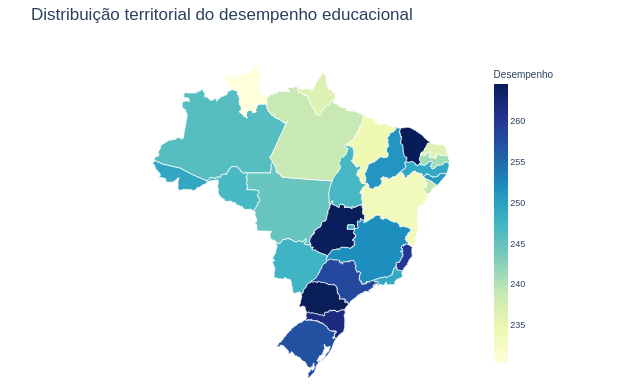

In [11]:
import geopandas as gpd
gdf = gpd.read_file("https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"); gdf["sigla"] = gdf["sigla"].str.upper(); mapa = gdf.merge(df_final,on="sigla")
fig = px.choropleth(mapa,geojson=mapa.geometry,locations=mapa.index,color="desempenho",hover_name="estado",hover_data={"desempenho":":.1f","renda":":.1f","pobreza":":.1f"},color_continuous_scale="YlGnBu",projection="mercator",title="Distribuição territorial do desempenho educacional")
fig.update_traces(marker_line_color="white",marker_line_width=0.8,hovertemplate="<b>%{hovertext}</b><br>Desempenho: %{customdata[0]:.1f}<br>Renda: %{customdata[1]:.1f}<br>Pobreza: %{customdata[2]:.1f}<extra></extra>")
fig.update_geos(fitbounds="locations",visible=False); fig.update_layout(width=620,height=390,margin=dict(l=0,r=0,t=40,b=0),coloraxis_colorbar=dict(x=0.78,title="Desempenho",thickness=14,len=0.9,tickfont=dict(size=9),title_font=dict(size=10)))
fig.write_image("mapa_desempenho.png")
from IPython.display import Image
Image("mapa_desempenho.png")

**Maiores desempenhos educacionais observados:**

1. Ceará: **264,6**
2. Paraná: **264,5**
3. Goiás: **264,3**
4. Santa Catarina: **261,8**
5. Espírito Santo: **260,1**

**Menores desempenhos educacionais observados:**


23. Amapá: **236,6**
24. Rio Grande do Norte: **236,4**
25. Maranhão: **234,4**
26. Bahia: **233,6**
27. Roraima: **230,4**

O resultado do **Ceará** se destaca por apresentar o maior desempenho médio das escolas públicas da análise, mesmo com níveis elevados de pobreza e renda média relativamente inferior aos estados mais desenvolvidos do país das regiões Sul e Sudeste.

Esse comportamento sugere que fatores institucionais e políticas educacionais também podem influenciar os resultados além das condições socioeconômicas. Nas últimas décadas, o Ceará passou a receber destaque nacional por avanços em alfabetização e acompanhamento educacional. O estado será retomado posteriormente como referência comparativa nas discussões sobre priorização e possíveis estratégias de intervenção educacional.

### 5.1.2 Comparação regional do desempenho educacional

O boxplot abaixo permite comparar a distribuição do desempenho educacional entre as regiões brasileiras, destacando diferenças de mediana, dispersão e variação entre os estados de cada região.

Quanto maior a altura do boxplot e dos whiskers, maior a variação do desempenho entre os estados da região.


In [12]:
fig = px.box(df_final,x="regiao",y="desempenho",color="regiao",color_discrete_map=cores_regiao,title="Distribuição regional do desempenho educacional",template="plotly_white")
fig.update_layout(width=750,height=450,xaxis_title="",yaxis_title="Desempenho médio",legend_title="")
fig.show()

- A região **Sul** apresentou os maiores níveis de desempenho educacional e menor dispersão entre os estados.
- O **Sudeste** também apresentou desempenho elevado, com resultados relativamente homogêneos.
- As regiões **Norte** e **Nordeste** concentraram os menores desempenhos médios.
- O **Nordeste** apresentou a maior dispersão entre os estados, indicando maior desigualdade regional nos resultados educacionais.

### 5.1.3 Diferenças entre redes pública e privada

Além do desempenho da rede pública, também foi realizada uma comparação exploratória entre os resultados médios das redes pública e privada nos estados brasileiros.

A análise permite observar diferenças entre as redes de ensino e possíveis desigualdades educacionais entre os estados analisados.

Para facilitar a visualização comparativa, os estados foram organizados em ordem crescente de desempenho da rede pública.

In [13]:
df_redes = df_final[["estado","sigla","desempenho","desempenho_privado"]].copy(); df_redes = df_redes.sort_values(by="desempenho")
df_redes["gap"] = df_redes["desempenho_privado"] - df_redes["desempenho"]
df_redes = df_redes.melt(id_vars=["estado","sigla","gap"],value_vars=["desempenho","desempenho_privado"],var_name="rede",value_name="desempenho_medio"); df_redes["rede"] = df_redes["rede"].replace({"desempenho":"Rede pública","desempenho_privado":"Rede privada"})
fig = px.bar(df_redes,x="sigla",y="desempenho_medio",color="rede",barmode="group",template="plotly_white",title="Desempenho médio das redes pública e privada por estado",color_discrete_map={"Rede pública":"#7FCDBB","Rede privada":"#225EA8"}); fig.update_layout(xaxis_title="Estado",yaxis_title="Desempenho médio",legend_title="",xaxis_tickfont=dict(size=10),bargap=0.18,bargroupgap=0.03)
fig.show()

- Os resultados mostram desempenho superior da rede privada em todas as regiões analisadas.
- **Rio Grande do Norte**, **Sergipe** e **Minas Gerais** apresentaram as maiores diferenças entre as redes pública e privada, com gaps superiores a **54 pontos** no desempenho médio observado.
- **Paraná**, **Ceará** e **São Paulo** apresentaram as menores diferenças relativas entre as redes de ensino analisadas.
- O **Ceará** destacou-se novamente pelo elevado desempenho da rede pública, aproximando-se relativamente dos resultados observados na rede privada quando comparado a outros estados.
- Os resultados sugerem que diferenças entre as redes pública e privada não seguem exatamente um padrão regional único, já que estados de diferentes regiões apareceram tanto entre os maiores quanto entre os menores gaps observados.

## 5.2 Contexto socioeconômico e desempenho educacional

Para integrar diferentes dimensões socioeconômicas em uma única visualização, foi construída uma análise inspirada no famoso gráfico **Gapminder**, utilizado para explorar relações entre desenvolvimento econômico, saúde e qualidade de vida entre países.

Referência: https://www.gapminder.org/tools/

Nesta adaptação:

- **cada bolha**: representa um estado brasileiro
- **eixo horizontal**: representa a renda domiciliar per capita
- **eixo vertical**: representa um indicador socioeconômico
- **tamanho da bolha**: inicialmente representa a população e depois o desempenho educacional
- **cor**: representa a região do país

O objetivo da visualização é integrar múltiplos indicadores em um único gráfico, permitindo observar padrões regionais, contextos de vulnerabilidade e possíveis exceções dentro da análise.

### 5.2.1 População, renda e desempenho educacional

Foi analisada a relação entre **renda** domiciliar per capita e desempenho educacional.

A variável `população` representa o tamanho das bolhas. Foi utilizada principalmente para contextualização visual e comparação territorial entre os estados, em uma releitura inspirada no modelo de visualização do Gapminder.

In [14]:
df_final["pop_size"] = (df_final["populacao"]**0.8)/945
labels=df_final["sigla"].mask(df_final["sigla"].isin(["AP"]),"")
fig = px.scatter(df_final,x="renda",y="desempenho",size="pop_size",color="regiao",hover_name="estado",text=labels,size_max=28,opacity=0.60,color_discrete_map=cores_regiao,template="plotly_white",title="População, renda e desempenho educacional"); fig.update_layout(xaxis_title="Renda domiciliar per capita (R$)",yaxis_title="Desempenho",xaxis=dict(range=[920,3507])); fig.update_traces(textposition="top center",textfont=dict(size=9.5),marker=dict(line=dict(width=1,color="white")))
fig.show()

- Os maiores níveis de renda concentraram-se principalmente nas regiões **Sul**, **Sudeste** e **Centro-Oeste**.
- O **Distrito Federal** apresentou renda significativamente superior aos demais estados.
- Estados das regiões **Norte** e **Nordeste** concentraram os menores níveis de renda domiciliar per capita.
- O gráfico sugere que o tamanho populacional, isoladamente, não explica os padrões de desempenho educacional observados


### 5.2.2 Pobreza, renda e desempenho

Foi analisada a relação entre renda domiciliar per capita, **taxa de pobreza** e desempenho educacional.

A variável `desempenho` representa o tamaho das bolhas neste e no próximo gráfico.

A taxa de pobreza representa o percentual da população com renda domiciliar per capita abaixo da linha de pobreza utilizada pelo IBGE, equivalente a aproximadamente **R$ 665** mensais por pessoa em 2023.

O eixo vertical foi invertido para que estados com menores taxas de pobreza apareçam visualmente nas posições mais altas do gráfico.

In [15]:
df_final["desempenho_size"] = ((df_final["desempenho"] - df_final["desempenho"].min()) ** 1.5) * 4.5 + 13
labels=df_final["sigla"].mask(df_final["sigla"].isin(["PE","AM","BA","MT","ES"]),"")
fig = px.scatter(df_final,x="renda",y="pobreza",size="desempenho_size",color="regiao",hover_name="estado",text=labels,size_max=28,opacity=0.66,color_discrete_map=cores_regiao,template="plotly_white",title="Pobreza, renda e desempenho educacional"); fig.update_yaxes(autorange="reversed"); fig.update_layout(xaxis_title="Renda domiciliar per capita (R$)",yaxis_title="Taxa de pobreza (%)",xaxis=dict(range=[920,3507])); fig.update_traces(textposition="top center",textfont=dict(size=10.3),marker=dict(line=dict(width=1,color="white")))
fig.show()

- Estados das regiões **Sul** e **Sudeste** concentraram maiores níveis de renda e menores taxas de pobreza.
- Estados do **Norte** e **Nordeste** concentraram, em geral, maiores níveis de vulnerabilidade socioeconômica.
- **Maranhão** apresentou a menor renda média da análise (**R$ 1.019**) e uma das maiores taxas de pobreza (**54,1%**).
- **Santa Catarina** apresentou a menor taxa de pobreza (**12,6%**), uma das maiores rendas e um dos maiores desempenhos educacionais observados.
- O **Distrito Federal** apresentou o maior nível de renda domiciliar per capita da análise (**R\$ 3.444**).

Apesar da tendência regional observada, alguns estados apresentaram desempenho educacional acima do esperado em relação ao próprio contexto socioeconômico, sugerindo influência de fatores institucionais e políticas educacionais.

### 5.2.3 Desigualdade, renda e desempenho

Além da pobreza, também foi analisada a desigualdade de renda por meio do Índice de Gini, utilizado como medida de concentração de renda dentro dos estados brasileiros.

O Índice de Gini varia entre **0 e 1**, onde valores mais altos indicam maior desigualdade social e maior concentração de renda.

Novamente, o eixo vertical foi invertido para que estados com menores níveis de desigualdade apareçam visualmente nas posições mais altas da análise.

In [16]:
labels=df_final["sigla"].mask(df_final["sigla"].isin(["PB","AM","PE","SE","ES"]),"")
fig = px.scatter(df_final,x="renda",y="gini",size="desempenho_size",color="regiao",hover_name="estado",text=labels,size_max=27,opacity=0.58,color_discrete_map=cores_regiao,template="plotly_white",title="Desigualdade, renda e desempenho educacional")
fig.update_yaxes(autorange="reversed"); fig.update_layout(xaxis_title="Renda domiciliar per capita (R$)",yaxis_title="Índice de Gini",xaxis=dict(range=[920,3507]),legend_title=""); fig.update_traces(textposition="top center",textfont=dict(size=10.5),marker=dict(line=dict(width=1,color="white")))
fig.show()

- A região **Sul** apresentou, em geral, estados com menores níveis de desigualdade escolar e de renda.
- Estados do **Norte** e **Nordeste** concentraram maiores níveis de pobreza e menores níveis de renda, mas nem sempre os maiores índices de desigualdade.
- O **Distrito Federal** apresentou o terceiro maior índice de desigualdade da análise (**0,54**), mesmo possuindo a maior renda média do país.
- **São Paulo** e **Rio de Janeiro** também apresentaram níveis elevados de desigualdade, apesar de possuírem algumas das maiores rendas médias da análise.
- **Santa Catarina** apresentou simultaneamente baixa pobreza, baixa desigualdade (**0,42**) e um dos maiores desempenhos educacionais observados.

Os resultados mostram que renda média e pobreza não representam, isoladamente, toda a complexidade das desigualdades sociais entre os estados brasileiros. Em alguns contextos, elevados níveis de renda coexistem com forte concentração de renda e desigualdade social, representando dimensões diferentes da vulnerabilidade social.

## 5.3 Urbanização e desempenho educacional

A taxa de urbanização foi analisada como um fator complementar ao contexto educacional e socioeconômico dos estados brasileiros.

O Brasil apresenta população majoritariamente urbana, com média de urbanização próxima de **85%** entre os estados analisados.

Em geral, estados mais urbanizados tendem a apresentar maior acesso à infraestrutura, serviços públicos e conectividade, fatores que podem influenciar as condições educacionais.

In [17]:
fig = px.scatter(df_final,x="desempenho",y="urbanizacao",color="regiao",hover_name="estado",text="sigla",color_discrete_map=cores_regiao,template="plotly_white",title="Urbanização e desempenho educacional")
fig.update_traces(textposition="top center",textfont=dict(size=11.5),marker=dict(size=10,line=dict(width=1,color="white")))
fig.update_layout(xaxis_title="Desempenho médio",yaxis_title="Taxa de urbanização (%)",legend_title="")
fig.show()

- Estados das regiões **Sul**, **Sudeste** e **Centro-Oeste** concentraram os maiores níveis de urbanização da análise.
- Estados das regiões **Norte** e **Nordeste** concentraram, em geral, menores taxas de urbanização.
- **Distrito Federal**, **Rio de Janeiro** e **São Paulo** apresentaram urbanização acima de **96%**.

Os resultados indicam uma tendência de associação entre urbanização e desempenho educacional.

## 5.4 Escolaridade da população adulta e desempenho educacional

Por fim, foi analisada a relação entre escolaridade da população adulta e desempenho educacional. A média do Brasil para o o ano analizado (2023) foi de aproximadamente **54%**

A escolaridade média da população pode refletir fatores históricos, acesso à educação e condições socioeconômicas associadas ao contexto educacional dos estados brasileiros.

In [18]:
fig = px.scatter(df_final,x="desempenho",y="escolaridade",color="regiao",hover_name="estado",text="sigla",color_discrete_map=cores_regiao,template="plotly_white",title="Escolaridade da população adulta e desempenho educacional")
fig.update_traces(textposition="top center",textfont=dict(size=10),marker=dict(size=12,line=dict(width=1,color="white")))
fig.update_layout(xaxis_title="Desempenho médio",yaxis_title="Escolaridade da população adulta (%)",legend_title="")
fig.show()

- O **Distrito Federal** apresentou o maior nível de escolaridade da população adulta da análise (**73,5%**).
- Diferentemente das análises anteriores, os estados da região **Sul** não se destacaram entre os maiores níveis de escolaridade média da população adulta.
- Estados como o **Ceará** apresentaram níveis relativamente baixos de escolaridade da população adulta (**45%**) mesmo com desempenho educacional elevado, enquanto estados do **Norte**, como **Roraima**, **Amapá** e **Amazonas**, apresentaram comportamento inverso.
- Outros estados do **Nordeste**, como **Piauí**, **Pernambuco** e **Alagoas**, também apresentaram baixa escolaridade média da população adulta apesar do desempenho educacional relativamente elevado.

Os resultados sugerem que escolaridade da população adulta e desempenho educacional não apresentam relação linear direta entre os estados analisados, indicando que fatores institucionais e políticas educacionais também podem exercer influência relevante sobre o desempenho observado.

## 5.5 Correlação entre variáveis

Para complementar a análise exploratória, foi construída uma matriz de correlação entre os principais indicadores utilizados no projeto.

A correlação mede o grau de relação linear entre duas variáveis, variando entre **-1** e **1**:

- valores próximos de **1** indicam correlação positiva forte
- valores próximos de **-1** indicam correlação negativa forte
- valores próximos de **0** indicam baixa correlação linear

Em variáveis como **pobreza** e **desigualdade (gini)**, correlações com valores mais **negativos** indicam que melhores condições socioeconômicas estão associadas a melhores resultados educacionais.

Essa etapa auxilia na identificação de variáveis mais associadas ao desempenho educacional e contribui para interpretação das relações observadas nas análises anteriores.

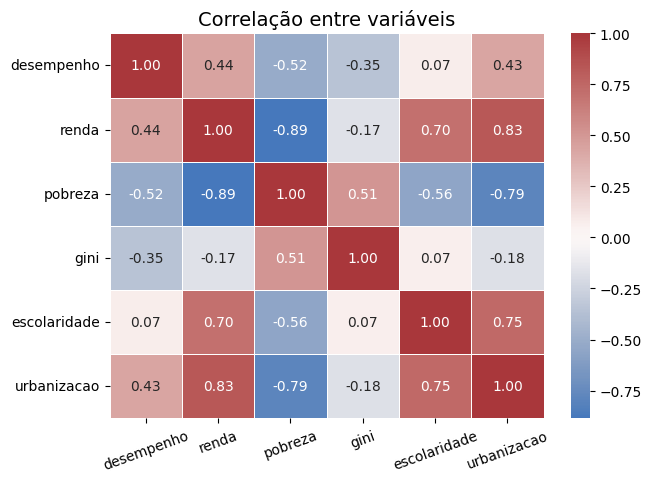

In [19]:
import matplotlib.pyplot as plt; import seaborn as sns
corr = df_final[["desempenho","renda","pobreza","gini","escolaridade","urbanizacao"]].corr(); plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap="vlag",center=0,linewidths=0.5,fmt=".2f")
plt.title("Correlação entre variáveis", fontsize=14); plt.xticks(rotation=20); plt.yticks(rotation=0)
plt.show()

- A taxa de pobreza apresentou a maior associação linear com o desempenho educacional (**-0,52**), indicando que contextos de maior vulnerabilidade social tendem a apresentar menores níveis de desempenho.
- O desempenho educacional apresentou correlação moderada com renda (**0,44**), urbanização (**0,43**) e Índice de Gini (**-0,35**).
- Escolaridade apresentou correlação praticamente nula com desempenho educacional (**0,07**), reforçando padrões observados em estados como **Ceará**, **Piauí** e **Pernambuco**.
- A maior correlação observada na análise ocorreu entre renda e pobreza (**-0,89**).

Os resultados sugerem que o desempenho educacional está associado a múltiplas dimensões socioeconômicas. Essas relações servirão de base para as próximas etapas de regressão, segmentação e priorização de contextos para intervenção educacional.

# 6. Relação entre variáveis e regiões (regressão linear)

Após a análise exploratória e da matriz de correlação, foi utilizada regressão linear simples para investigar tendências entre indicadores socioeconômicos e desempenho educacional.

Nesta etapa, foram priorizadas a relação do desempenho escolar com as variáveis que apresentaram associações mais relevantes com durante a análise exploratória:
* `desempenho` x `renda`
* `desempenho` x `pobreza`

Cada variável priorizada criou 2 regressões considerando:

1. o conjunto geral dos estados brasileiros
2. a relação entre as regiões do país

Além da visualização gráfica, a regressão permite observar:

- **direção da relação:** linhas inclinadas para cima indicam tendência positiva; linhas inclinadas para baixo indicam tendência negativa
- **intensidade da relação:** inclinações mais acentuadas indicam relações mais fortes entre as variáveis
- **dispersão dos estados:** distribuições mais espalhadas em torno da linha indicam maior variabilidade entre os contextos analisados




## 6.1 Renda e desempenho educacional

Inicialmente, foi analisada a relação entre renda domiciliar per capita e desempenho educacional.


Coeficiente da renda: 0.0076


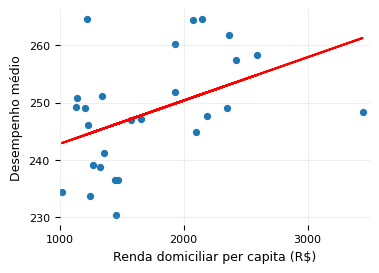

In [20]:
from sklearn.linear_model import LinearRegression
X = df_final[["renda"]]; y = df_final["desempenho"]
model = LinearRegression(); model.fit(X, y); coef_renda = model.coef_[0]; print(f"Coeficiente da renda: {coef_renda:.4f}")
plt.figure(figsize=(4,2.8)); plt.scatter(X,y,s=18); plt.plot(X,model.predict(X),color="red",linewidth=1.5);plt.xlim(1000,3500); plt.xticks([1000,2000,3000],fontsize=8); plt.yticks([230,240,250,260],fontsize=8);plt.xlabel("Renda domiciliar per capita (R$)",fontsize=9); plt.ylabel("Desempenho médio",fontsize=9); plt.grid(alpha=0.2); plt.box(False)
plt.show()

O coeficiente positivo da regressão (**0.0076**) e a linha inclinada para cima indicam tendência de aumento do desempenho educacional no Brasil conforme o crescimento da renda domiciliar per capita.

In [21]:
coef_regiao={}
for r in df_final["regiao"].unique():
    df_r=df_final[df_final["regiao"]==r]; X=df_r[["renda"]]; y=df_r["desempenho"]; coef_regiao[r]=LinearRegression().fit(X,y).coef_[0]
df_final["legenda"]=df_final["regiao"].map(lambda x:f"{x}: {coef_regiao[x]:.4f}")
fig=px.scatter(df_final,x="renda",y="desempenho",color="legenda",text="sigla",trendline="ols",hover_name="estado",template="plotly_white",color_discrete_map={f"{k}: {coef_regiao[k]:.4f}":v for k,v in cores_regiao.items()},title="Renda domiciliar per capita e desempenho educacional"); fig.update_traces(textposition="top center",textfont=dict(size=10.5));fig.update_layout(xaxis_title="Renda domiciliar per capita (R$)",yaxis_title="Desempenho médio",legend_title_text="")
fig.show()

Apesar das inclinações negativas observadas nas análises regionais, a regressão agregada do Brasil apresentou tendência positiva entre renda domiciliar per capita e desempenho educacional. Isso ocorre porque regiões com maior renda média também concentram maiores níveis de desempenho, produzindo um efeito agregado diferente das tendências observadas dentro de cada região.

- **Sul:** apresentou a maior inclinação negativa entre renda e desempenho educacional, com a linha de tendência posicionada nos níveis mais altos de desempenho.
- **Nordeste:** apresentou tendência negativa leve e a maior dispersão do desempeho médio entre os estados da região, com contraste relevante entre Ceará e Maranhão.
- **Centro-Oeste:** apresentou a linha de tendência mais longa, influenciado principalmente pela elevada renda do Distrito Federal.
- **Sudeste:** apresentou relação praticamente estável entre renda e desempenho educacional.
- **Norte:** apresentou a linha de tendência posicionada abaixo das demais regiões.

## 6.2 Pobreza e desempenho educacional

Em seguida, foi analisada a relação entre taxa de pobreza e desempenho educacional utilizando a mesma abordagem.

Diferentemente da análise de renda, nesta etapa linhas inclinadas para baixo indicam associação entre aumento da pobreza e redução do desempenho educacional.

Coeficiente da pobreza: -0.3564


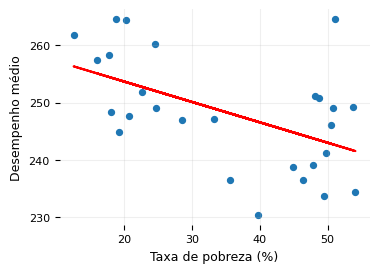

In [22]:
X = df_final[["pobreza"]]; y = df_final["desempenho"]
model = LinearRegression(); model.fit(X, y)
coef_pobreza = model.coef_[0]; print(f"Coeficiente da pobreza: {coef_pobreza:.4f}")
plt.figure(figsize=(4,2.8));plt.scatter(X,y,s=18);plt.plot(X,model.predict(X),color="red",linewidth=1.5);plt.xticks(fontsize=8);plt.yticks([230,240,250,260],fontsize=8);plt.xlabel("Taxa de pobreza (%)",fontsize=9);plt.ylabel("Desempenho médio",fontsize=9);plt.grid(alpha=0.2);plt.box(False)
plt.show()

O coeficiente negativo da regressão indica tendência de redução do desempenho educacional conforme o aumento da taxa de pobreza, indicando uma linha para baixo.


In [23]:
coef_regiao={}
for r in df_final["regiao"].unique():
    df_r=df_final[df_final["regiao"]==r]; X=df_r[["pobreza"]]; y=df_r["desempenho"]; coef_regiao[r]=LinearRegression().fit(X,y).coef_[0]
df_final["legenda"]=df_final["regiao"].map(lambda x:f"{x}: {coef_regiao[x]:.4f}")
fig=px.scatter(df_final,x="pobreza",y="desempenho",color="legenda",text="sigla",trendline="ols",hover_name="estado",template="plotly_white",color_discrete_map={f"{k}: {coef_regiao[k]:.4f}":v for k,v in cores_regiao.items()},title="Taxa de pobreza e desempenho educacional"); fig.update_traces(textposition="top center",textfont=dict(size=10.5)); fig.update_layout(xaxis_title="Taxa de pobreza (%)",yaxis_title="Desempenho médio",legend_title_text="")
fig.show()

Apesar da regressão agregada do Brasil apresentar tendência negativa entre taxa pobreza e desempenho educacional, as análises regionais, com exceção do Sudeste, mostraram tendências positivas. Isso ocorre porque estados de uma mesma região podem possuir níveis de desempenho relativamente próximos mesmo com diferenças importantes de pobreza, além da pequena quantidade de estados por região tornar as linhas de tendência mais sensíveis a casos específicos.

- **Sul:** apresentou baixos níveis de pobreza, com tendência positiva leve entre os estados da região.
- **Nordeste:** apresentou maior dispersão entre os estados, com contraste relevante entre Ceará e Maranhão.
- **Sudeste:** foi a única região que apresentou tendência negativa entre pobreza e desempenho educacional.
- **Centro-Oeste:** apresentou forte inclinação positiva.
- **Norte:** apresentou a linha de tendência mais longa da análise, refletindo maior amplitude de pobreza entre os estados da região.

> As regressões regionais apresentaram limitações para identificar padrões mais consistentes entre os estados brasileiros, devido às diferenças estruturais entre as regiões e à influência de estados com características muito específicas. Dessa forma, na próxima etapa será utilizada uma abordagem de clusterização, agrupando estados com características socioeconômicas e educacionais semelhantes independentemente da região geográfica.

# 7. Segmentação de Contextos Educacionais (Clustering)

Até esta etapa, a análise explorou principalmente diferenças regionais e relações entre indicadores socioeconômicos e desempenho educacional das escolas públicas brasileiras.

No entanto, estados de uma mesma região podem apresentar contextos bastante diferentes entre si.

Para complementar a análise, foi aplicada uma técnica de clustering para identificar grupos de estados com perfis socioeconômicos e educacionais semelhantes, independentemente da localização geográfica.


## 7.1 Construção dos Clusters

A segmentação foi construída utilizando os indicadores:

- desempenho educacional
- renda domiciliar per capita
- taxa de pobreza
- índice de Gini
- taxa de urbanização

As variáveis foram selecionadas com base nas análises e regressões realizadas anteriormente. Foi priorizado indicadores observados com maior relação entre vulnerabilidade socioeconômica e desempenho educacional e retirado a variável `escolaridade` por apresentar menor capacidade de diferenciação entre os grupos identificados.

Foram testadas diferentes segmentações, sendo definidos três clusters principais por apresentarem melhor interpretabilidade para análise.

Os dados foram padronizados e segmentados utilizando o algoritmo K-Means.



In [24]:
from sklearn.preprocessing import StandardScaler; from sklearn.cluster import KMeans
X = df_final[["desempenho","renda","pobreza","gini","urbanizacao"]]
scaler = StandardScaler(); X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df_final["cluster"] = kmeans.fit_predict(X_scaled)

## 7.2 Análise dos Clusters

Após a segmentação, foram analisadas as médias dos indicadores em cada cluster identificado.

In [25]:
cluster_summary = df_final.groupby("cluster")[["desempenho","renda","pobreza","gini","urbanizacao"]].mean().round({"desempenho":1,"renda":1,"pobreza":1,"gini":2,"urbanizacao":1})
cluster_summary

,desempenho,renda,pobreza,gini,urbanizacao
cluster,,,,,
0,254.0,2215.1,21.4,0.48,89.2
1,239.7,1288.2,47.1,0.51,79.9
2,255.0,1232.0,51.0,0.53,73.6


**Cluster 0: Contextos socioeconômicos mais favorecidos**

- maiores níveis médios de renda e urbanização
- menores taxas de pobreza
- desempenho educacional relativamente elevado


**Cluster 1: Maior vulnerabilidade socioeconômica**

- menor renda média
- maiores níveis de pobreza
- menor desempenho educacional médio

**Cluster 2: Contextos intermediários**

- elevada vulnerabilidade socioeconômica
- desempenho educacional acima do esperado para contextos semelhantes
- renda média mais baixa e pobreza relativamente alta



## 7.3 Visualização dos clusters e interpretação final

Para facilitar a visualização dos agrupamentos, foi criado um índice socioeconômico simplificado combinando  taxa de pobreza, índice gini e taxa de urbanização.

O objetivo desse indicador não é representar uma medida oficial, mas apenas apoiar a interpretação visual dos clusters no gráfico.

In [26]:
df_final["perfil_cluster"] = df_final["cluster"].map({0:"Menor vulnerabilidade",1:"Maior vulnerabilidade",2:"Contextos intermediários"})
df_final["indice_socioeconomico"] = -df_final["gini"]-df_final["pobreza"] + df_final["urbanizacao"]
fig = px.scatter(df_final,x="indice_socioeconomico",y="desempenho",color="perfil_cluster",symbol="perfil_cluster",text="sigla",hover_name="estado",template="plotly_white",title="Agrupamento socioeconômico e desempenho educacional",color_discrete_map={"Menor vulnerabilidade":"#4f81bd","Maior vulnerabilidade":"#c051a2","Contextos intermediários":"#f4b942"}); fig.update_traces(textposition="top center",textfont=dict(size=10),marker=dict(size=10,line=dict(width=1,color="white")),showlegend=True); fig.update_layout(xaxis_title="Índice socioeconômico agregado",yaxis_title="Desempenho educacional",legend_title="",coloraxis_showscale=False)
fig.show()

- o grupo de maior vulnerabilidade econômica  concentrou principalmente estados das regiões **Norte** e **Nordeste** com maior vulnerabilidade social e educacional.
- os estados **Ceará**, **Acre** e **Piauí**, foram agrupados como contextos intermediários por apresentaram desempenho educacional relativamente elevado mesmo em contextos socioeconômicos mais vulneráveis.
- **Rondônia** e **Tocantins** foram agrupados como menor vulnerabilidade mesmo sem apresentarem indicadores relativamente altos isoladamente, pois a segmentação considera simultaneamente todas as variáveis utilizadas na análise.

Os resultados evidenciam novamente diferenças importantes entre estados de uma mesma região, padrões que já foram observados nas análises exploratórias e regressões lineares.

Além das diferenças regionais, os agrupamentos mostram que desempenho educacional e contexto socioeconômico não seguem exatamente o mesmo comportamento entre os estados brasileiros.

# 8. Priorização de Intervenção Educacional (NOVO)

Após as análises exploratórias, regressões lineares e segmentações realizadas anteriormente, foi construída uma proposta simplificada de priorização de contextos educacionais para intervenção.

Esta etapa possui foco mais aplicado, integrando indicadores sociais e educacionais para apoiar processos de tomada de decisão.

A priorização foi construída em duas etapas principais:

1. construção de um score de vulnerabilidade socioeconômica
2. cruzamento entre vulnerabilidade e desempenho educacional para definição da prioridade de intervenção

O objetivo é identificar estados onde intervenções educacionais podem apresentar maior potencial de impacto.


## 8.1 Construção do score de vulnerabilidade socioeconômica

Inicialmente, foi criado um score de vulnerabilidade socioeconômica consolidando diferentes indicadores em uma única métrica comparativa.


Foram considerados:

- renda domiciliar per capita
- taxa de pobreza
- Índice de Gini (desigualdade)

De forma geral os maiores níveis de pobreza e desigualdade aumentam a vulnerabilidade e maiores níveis de renda reduzem a vulnerabilidade.

As variáveis foram ponderadas da seguinte forma:

- **pobreza** (**1.3**): recebeu maior peso devido à forte relação observada com vulnerabilidade social e desempenho educacional ao longo da análise
- **renda** (**1.1**): foi utilizada como indicador complementar de contexto socioeconômico
- **gini** (**1.0**): foi mantido para representar desigualdades estruturais entre os estados


Como as variáveis apresentam escalas diferentes, os dados foram padronizados antes da construção do score.

In [27]:
features = ["renda", "pobreza", "gini"]; scaler = StandardScaler(); df_scaled = pd.DataFrame(scaler.fit_transform(df_final[features]), columns=features)
df_final["score_vulnerabilidade"] = (-(df_scaled["renda"] * 1.1) + (df_scaled["pobreza"] * 1.3) + (df_scaled["gini"] * 1.0))
df_score = df_final[["estado","regiao","score_vulnerabilidade"]].sort_values(by="score_vulnerabilidade", ascending=False).reset_index(drop=True); df_score["ranking"] = range(1, len(df_score) + 1); df_score = df_score[["ranking","estado","regiao","score_vulnerabilidade"]]
fig = px.bar(df_score,x="estado",y="score_vulnerabilidade",color="regiao",color_discrete_map=cores_regiao,template="plotly_white",title="Score de vulnerabilidade socioeconômica por estado"); fig.update_layout(xaxis_title="Estado",yaxis_title="Score de vulnerabilidade",legend_title_text="",xaxis=dict(tickfont=dict(size=10))); fig.update_xaxes(categoryorder="total descending")
fig.show()

- Os resultados mostram maior concentração de vulnerabilidade socioeconômica em estados das regiões **Norte** e **Nordeste**.
- **Paraíba**, **Piauí** e **Acre** apresentaram os maiores níveis de vulnerabilidade socioeconômica da análise.
- O **Ceará** também apresentou vulnerabilidade relativamente elevada, apesar do desempenho educacional acima da tendência observada para contextos socioeconômicos semelhantes.

## 8.2 Construção do indicador de prioridade de intervenção

Após a construção do score de vulnerabilidade, foi realizado o cruzamento com desempenho educacional para definição de um indicador de intervenção educacional.


Enquanto o score anterior considerava priorizar apenas estados com baixos níveis estruturais e socioeconômicos, esta etapa incorpora a variável `desempenho`, para a identificação de priorização de estados onde intervenções educacionais podem apresentar maior potencial de impacto no desempenho escolar.

Aumentam a prioridade estados com:

- maiores níveis de vulnerabilidade
- menores níveis de desempenho educacional

Para a criação de a variável `prioridade_intervencao`, o desempenho educacional foi padronizado e recebeu peso adicional de **2.5**, ampliando sua influência sobre o indicador.

O indicador seguiu a seguinte lógica:

- `score_vulnerabilidade` + (`desempenho_padronizado` **× 2.5**)



In [28]:
desempenho_padronizado = StandardScaler().fit_transform(df_final[["desempenho"]])
df_final["prioridade_intervencao"] = (df_final["score_vulnerabilidade"] - desempenho_padronizado.flatten() * 2.5)

Após o cálculo do indicador, foi definida uma  faixa de prioridade, onde os estados foram organizados em três grupos principais de prioridade com diferentes pesos para os valores da prioridade de intervenção:

- `Alta prioridade`: valores acima de **4.0**
- `Prioridade moderada`: valores entre **4.0** e **0**
- `Menor prioridade`: valores abaixo de **0**

In [29]:
def classificar_prioridade(valor):
    if valor >= 4.0:
        return "Alta prioridade"
    elif valor >= 0:
        return "Prioridade moderada"
    else:
        return "Menor prioridade"
df_final["faixa_prioridade"] = df_final["prioridade_intervencao"].apply(classificar_prioridade)

## 8.3 Visualização do ranking de prioridades e observações finais


A classificação foi definida a partir da distribuição dos resultados observados na análise. Abaixo a visualização do ranking de prioridade.

In [30]:
df_plot = df_final.sort_values(by="prioridade_intervencao", ascending=False)
cores_prioridade = {"Alta prioridade": "#D95F02","Prioridade moderada": "#F2CF5B","Menor prioridade": "#4C78A8"}
fig = px.bar(df_plot,x="estado",y="prioridade_intervencao",color="faixa_prioridade",color_discrete_map=cores_prioridade,template="plotly_white",title="Priorização de contextos para intervenção educacional",text="prioridade_intervencao"); fig.update_traces(texttemplate="%{text:.1f}",textposition="outside"); fig.update_layout(xaxis_title="Estado",yaxis_title="Prioridade de intervenção",legend_title_text="",xaxis=dict(tickfont=dict(size=10)))
fig.show()

- **Maranhão** apresentou o maior nível relativo de prioridade da análise (**6.5**), seguido por **Roraima** (**6.3**), **Paraíba** (**5.8**) e **Bahia** (**5.8**).
- Estados como **Ceará**, **Piauí** e **Alagoas** apresentaram elevada vulnerabilidade socioeconômica, mas desempenho educacional relativamente superior ao observado em outros contextos semelhantes, reduzindo sua prioridade relativa na análise final.
- Assim como na etapa de clusterização, os resultados evidenciam que vulnerabilidade socioeconômica e desempenho educacional não seguem exatamente o mesmo comportamento entre os as regiões do Brasil, reforçando a importância de análises multidimensionais para apoiar decisões de intervenção educacional.

A priorização servirá como base para as próximas etapas de simulação e proposta do piloto educacional orientado por dados.


# 9. Proposta de piloto educacional orientado por dados

Com base nos resultados observados ao longo da análise, foi construída uma proposta simplificada de piloto educacional orientado por dados, voltada a estados classificados como alta prioridade de intervenção.

A proposta busca demonstrar como indicadores educacionais e socioeconômicos podem apoiar decisões relacionadas à definição de prioridades, acompanhamento de resultados e direcionamento de políticas educacionais.




## 9.1 Contextos prioritários para intervenção

Os resultados anteriores mostraram maior concentração de estados prioritários nas regiões Norte e Nordeste.

Após o cruzamento entre vulnerabilidade socioeconômica e desempenho educacional, os estados com maior prioridade relativa de intervenção foram:

In [31]:
top_prioridade = (df_final[["estado","prioridade_intervencao"]].sort_values(by="prioridade_intervencao", ascending=False).head(7).reset_index(drop=True))
top_prioridade.index = top_prioridade.index + 1
top_prioridade

,estado,prioridade_intervencao
1,MARANHÃO,6.542017
2,RORAIMA,6.273133
3,PARAÍBA,5.840634
4,BAHIA,5.800728
5,RIO GRANDE DO NORTE,5.779088
6,SERGIPE,4.721350
7,PARÁ,4.235474


O mapa abaixo apresenta a distribuição territorial da priorização de intervenção educacional construída ao longo da análise.

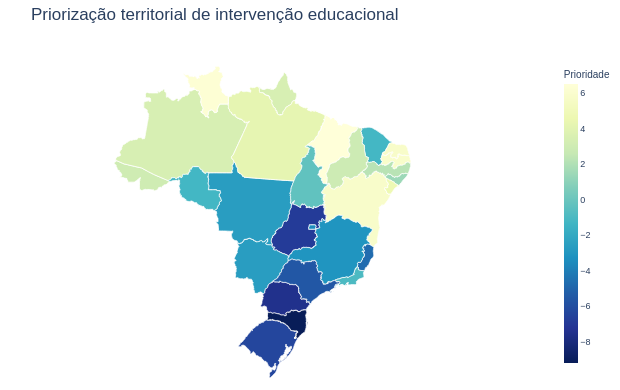

In [32]:
gdf = gpd.read_file("https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson")
gdf["sigla"] = gdf["sigla"].str.upper(); mapa = gdf.merge(df_final,on="sigla")
fig = px.choropleth(mapa,geojson=mapa.geometry,locations=mapa.index,color="prioridade_intervencao",hover_name="estado",hover_data={"faixa_prioridade":True,"desempenho":":.1f","prioridade_intervencao":False},color_continuous_scale="YlGnBu_r",projection="mercator",title="Priorização territorial de intervenção educacional");fig.update_traces(marker_line_color="white",marker_line_width=0.8,hovertemplate="<b>%{hovertext}</b><br>Classificação: %{customdata[0]}<br>Desempenho público: %{customdata[1]:.1f}<extra></extra>")
fig.update_geos(fitbounds="locations",visible=False); fig.update_layout(width=620,height=390,margin=dict(l=0,r=0,t=40,b=0),coloraxis_colorbar=dict(title="Prioridade",thickness=14,len=0.9,tickfont=dict(size=9),title_font=dict(size=10)))
fig.write_image("mapa_prioridade.png")
from IPython.display import Image
Image("mapa_prioridade.png")

**Maranhão**, **Roraima**, **Paraíba**, **Bahia**, **Rio Grande do Norte**, **Sergipe** e **Pará** apresentaram os maiores níveis relativos de prioridade de intervenção da análise.

Esses contextos combinam simultaneamente:

- elevada vulnerabilidade socioeconômica
- desempenho educacional relativamente mais baixo
- maior potencial relativo de impacto para intervenções educacionais direcionadas



## 9.2 Caso de referência: Ceará

Durante o projeto, o **Ceará** apresentou um dos resultados mais relevantes do projeto.
Apesar de possuir indicadores socioeconômicos semelhantes aos observados em parte dos estados classificados como alta prioridade, o estado apresentou o maior desempenho educacional médio da rede pública entre os estados analisados.

Os resultados observados também são consistentes com indicadores educacionais nacionais recentes. Segundo resultados do **Ideb 2023**, o **Ceará** apresentou o melhor desempenho da rede pública do Brasil nos anos iniciais e finais do Ensino Fundamental. [Resultados do Ideb 2023 (INEP)](https://www.gov.br/inep/pt-br/areas-de-atuacao/pesquisas-estatisticas-e-indicadores/ideb/resultados)

Estudos sobre políticas educacionais no estado destacam principalmente:

- foco em alfabetização na idade certa
- acompanhamento contínuo da aprendizagem
- monitoramento de indicadores educacionais
- apoio técnico aos municípios
- metas de desempenho e gestão por resultados

Programas como o **PAIC (Programa Alfabetização na Idade Certa)** e o sistema estadual de avaliação **SPAECE** são frequentemente apontados como parte importante desse processo. [MAIS PAIC — Secretaria da Educação do Ceará](https://www.seduc.ce.gov.br/mais-paic/)

Nesse contexto, o **Ceará** foi utilizado neste projeto como referência para reflexão sobre estratégias de acompanhamento educacional e priorização orientada por dados.


## 9.3 Estrutura Proposta para o Piloto

Com base nos resultados observados ao longo da análise e nas estratégias identificadas no caso do **Ceará**, o piloto educacional proposto possui foco em escolas públicas localizadas em contextos classificados como alta prioridade de intervenção.

A proposta tem como objetivo apoiar a melhoria gradual de indicadores educacionais em contextos prioritários

**Principais frentes da proposta:**
- uso de tecnologia educacional
- reforço escolar
- acompanhamento pedagógico
- monitoramento contínuo de indicadores educacionais

**Estratégias inspiradas no caso do Ceará:**
- acompanhamento frequente da aprendizagem
- definição de metas educacionais
- uso de indicadores para monitoramento
- apoio técnico e pedagógico contínuo

A implementação inicial seria realizada em pequena escala, permitindo adaptação progressiva da proposta aos diferentes contextos locais.

A proposta não busca representar uma solução única para diferentes realidades educacionais, mas sim uma estrutura inicial de intervenção orientada por dados e priorização socioeducacional.

# 10. Monitoramento e Simulação do Piloto Educacional (NOVO)

Após a definição dos contextos prioritários e da estrutura proposta para o piloto, foi construída uma simulação simplificada de acompanhamento da intervenção educacional ao longo do tempo.

O objetivo desta etapa é ilustrar como indicadores educacionais podem apoiar processos de monitoramento, avaliação e acompanhamento contínuo em projetos educacionais orientados por dados.

## 10.1 Teoria da Mudança

A teoria da mudança é uma estrutura utilizada em projetos sociais e educacionais para representar, de forma lógica, como uma intervenção pode contribuir para geração de impacto ao longo do tempo.

Nesta proposta, ela foi utilizada para demonstrar como ações de apoio pedagógico e acompanhamento contínuo poderiam contribuir para melhoria gradual dos indicadores educacionais em contextos de maior vulnerabilidade social.

A lógica proposta para o piloto considera que intervenções direcionadas podem contribuir para:
- maior acompanhamento escolar
- aumento de participação e engajamento dos estudantes
- melhoria gradual do desempenho educacional

Estrutura da proposta:
- **Input** (intervenção)
  - implementação de tecnologia educacional
  - reforço escolar
  - apoio pedagógico
- **Output** (mudanças iniciais)
  - aumento de participação escolar
  - acompanhamento contínuo
  - maior engajamento educacional
- **Outcome** (resultado esperado)
  - melhoria gradual do desempenho
  - evolução dos indicadores educacionais

## 10.2 Indicadores de monitoramento (KPIs)

Para acompanhar a evolução do piloto ao longo do tempo, foram definidos indicadores simplificados de monitoramento relacionados ao desempenho e engajamento escolar.

**Indicadores de curto prazo**:
- frequência escolar
- participação nas atividades
- uso de ferramentas educacionais

**Indicadores de médio prazo**:
- evolução das avaliações escolares
- alfabetização
- acompanhamento pedagógico

**Indicadores de longo prazo**:
- desempenho educacional consolidado
- redução de desigualdades educacionais
- evolução de indicadores regionais

Os indicadores apresentados possuem caráter ilustrativo e buscam demonstrar como processos de acompanhamento contínuo podem apoiar intervenções educacionais orientadas por dados.


## 10.3 Simulação de acompanhamento do piloto

Para a simulação de acompanhamento, foram considerados quatro anos de evolução educacional e selecionados os seguintes estados classificados anteriormente como prioridade de intervenção educacional:

- **Maranhão**: maior prioridade relativa identificada na análise
- **Pará**: outro estado selecionado como alta prioridade de intervenção

O **Ceará** foi utilizado como referência comparativa devido ao desempenho educacional acima da tendência observada para estados com perfil socioeconômico semelhante, servindo como base comparativa para evolução dos estados priorizados ao longo do acompanhamento.

As variáveis abaixo representam:

- `Ano 1`: desempenho educacional inicial observado na análise
- `Ano 2` ao `Ano 4`: projeção simplificada de evolução gradual do desempenho ao longo do acompanhamento

In [33]:
df_piloto = pd.DataFrame({"estado":["Maranhão","Pará","Ceará"],"Ano 1":[234.4,238.8,264.6],"Ano 2":[238.5,241.5,265.0],"Ano 3":[242.0,244.2,266.0],"Ano 4":[245.5,247.0,267.0]});df_piloto.index = ["","",""]
df_piloto

,estado,Ano 1,Ano 2,Ano 3,Ano 4
,Maranhão,234.4,238.5,242.0,245.5
,Pará,238.8,241.5,244.2,247.0
,Ceará,264.6,265.0,266.0,267.0


A evolução simulada considera melhorias graduais e contínuas ao longo do acompanhamento educacional, sem pressupor mudanças imediatas ou redução completa das diferenças observadas entre os estados.

In [34]:
df_plot = df_piloto.melt(id_vars="estado",var_name="Ano",value_name="desempenho")
fig = px.line(df_plot,x="Ano",y="desempenho",color="estado",markers=True,template="plotly_white",title="Simulação de acompanhamento do piloto educacional",color_discrete_map={"Maranhão":"#3B82F6","Pará":"#14B8A6","Ceará":"#7C3AED"})
fig.update_layout(xaxis_title="Período de acompanhamento",yaxis_title="Desempenho educacional médio",legend_title="",yaxis_range=[220,280])
fig.show()

## 10.4 Principais Observações

- **Maranhão** apresentou evolução simulada de aproximadamente **4,7%** ao longo do período analisado.
- **Pará** apresentou crescimento aproximado de **3,4%**, mantendo evolução gradual durante o acompanhamento.
- O **Ceará** permaneceu como referência comparativa de desempenho educacional ao longo da simulação.

Os resultados ilustram como indicadores educacionais podem apoiar processos de monitoramento, acompanhamento contínuo e avaliação de intervenções educacionais orientadas por dados.

# 11. Conclusão

## 11.1 Principais conclusões

- O modelo de priorização construído permitiu identificar estados com maiores níveis relativos de vulnerabilidade socioeconômica e prioridade de intervenção educacional, concentrados principalmente nas regiões **Norte** e **Nordeste**, com destaque para **Maranhão**, **Roraima** e **Paraíba**.

- Os indicadores socioeconômicos analisados apresentaram relação relevante com o desempenho educacional da rede pública. No entanto, os resultados mostraram que fatores socioeconômicos não explicam isoladamente as diferenças observadas entre os estados.

- O **Ceará** destacou-se por apresentar o maior desempenho médio da rede pública da análise, mesmo em uma região com elevados níveis relativos de vulnerabilidade social. **Piauí** e **Pernambuco** tambem apresentaram desempenho relativamente superior comparados com outros contextos socioeconômicos semelhantes.



- Em contraste, estados com indicadores socioeconômicos mais favoráveis, como o **Distrito Federal**, não apresentaram desempenho educacional proporcionalmente superior quando comparados a outros estados da análise.

- Todos os estados apresentaram desempenho superior na rede privada em relação à rede pública. As maiores diferenças observadas ocorreram em **Rio Grande do Norte (+26.5%)** e **Sergipe (+23.9%)**, enquanto **Paraná (+4.3%)** e **Ceará (+7.5%)** apresentaram as menores diferenças relativas entre as redes.

- A análise de clusterização reforçou a importância de avaliar os estados individualmente, permitindo identificar perfis educacionais e socioeconômicos distintos além das divisões regionais.

- **Santa Catarina** apresentou um dos resultados mais equilibrados da análise, combinando elevado desempenho educacional (**261.8 pontos**), baixa pobreza (**12.6%**) e menor desigualdade social relativa (**Gini = 0.418**).

- A simulação de acompanhamento do piloto buscou demonstrar, de forma aplicada, como indicadores educacionais podem apoiar processos de monitoramento, priorização e avaliação contínua de políticas públicas orientadas por dados.

## 11.2 Aplicações práticas e limitações

A proposta desenvolvida ao longo do projeto demonstra como dados públicos podem apoiar processos de:

- priorização de políticas educacionais
- monitoramento de indicadores educacionais
- acompanhamento de metas de desempenho
- avaliação simplificada de impacto educacional

Entre as principais limitações da análise, destacam-se:

- utilização de dados agregados por estado
- ausência de séries históricas mais longas
- limitação de alguns indicadores públicos disponíveis
- utilização de simulações simplificadas no piloto educacional

Apesar dessas limitações, os resultados reforçam a importância de análises contextualizadas e do acompanhamento contínuo de indicadores educacionais e socioeconômicos em projetos de impacto social.

## 11.3 Possíveis expansões futuras

Possíveis expansões futuras do projeto incluem:

- análises em nível municipal
- utilização de séries históricas mais amplas
- integração com indicadores reais de acompanhamento escolar
- avaliação de políticas públicas educacionais específicas
- ampliação do piloto para contextos regionais mais detalhados
- comparação entre redes pública e privada de ensino
- desenvolvimento de modelos preditivos voltados à identificação de risco de evasão escolar